# <center> Avance EDA </center>


In [1]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns


## El equipo de marketing nos dió una base de datos para analizar y determinar cual es la mejor estrategia para mejorar las ventas de un restaurant objetivo

---------------------------------------------------------------------------------------------------------------------------------------------------------------------

##### Objetivo del Análisis: Identificar el perfil de cliente que genera mayores ingresos para el restaurante. Para esto, analizaremos la variable 'promedio_gasto_comida' cruzándola con datos demográficos, geográficos y poder adquisitivo, con el fin de definir una segmentación de marketing efectiva. En otras palabras encontraremos el perfil de el "mejor cliente", el que más consume, para que el equipo de marketing afine su segmentación actual.

...........................................................................................................................................................................................................

#### <span style="color:yellow">Lectura del archivo y tipo de datos</span>

In [2]:
#Lectura de archivo 

archivo_restaurantes = r"F:\CRISTIAN\CRISTIAN\CURSOS\CURSO HENRY\ANÁLISIS DE DATOS IA\M1\ProyectoM1_CristianDuran\Avances-Notebooks\base_datos_restaurantes_USA_v2.csv"
df_restaurantes = pd.read_csv(archivo_restaurantes, dtype={"telefono_contacto": str, "id_persona": str})


print(df_restaurantes.head())
print(df_restaurantes.dtypes)

   id_persona    nombre apellido  edad     genero ciudad_residencia  \
0  2550327378   Jackson    Gomez  31.0  Masculino             Miami   
1  9446112038  Samantha     Soto  40.0   Femenino            Denver   
2  3098363243     Terry    Adams  62.0   Femenino            Denver   
3  4013002847     James  Shannon  41.0  Masculino            Boston   
4  7372911048     Susan    Jones  49.0   Femenino         San Diego   

  estrato_socioeconomico  frecuencia_visita  promedio_gasto_comida ocio  \
0                   Alto                  6                  67.51   Sí   
1                  Medio                  2                  44.92   Sí   
2                   Bajo                  2                   9.24   Sí   
3                   Alto                  5                  30.74   Sí   
4                   Bajo                  0                   0.00   No   

  consume_licor preferencias_alimenticias membresia_premium telefono_contacto  \
0            No               Vegetariano

#### <span style="color:yellow">Filtrado por ciudad: Miami</span>

In [3]:
#Filtrado por la ciudad de Miami

archivo_restaurantes = r"F:\CRISTIAN\CRISTIAN\CURSOS\CURSO HENRY\ANÁLISIS DE DATOS IA\M1\ProyectoM1_CristianDuran\Avances-Notebooks\base_datos_restaurantes_USA_v2.csv"

df_ciudad_residencia_mi = pd.read_csv(archivo_restaurantes, usecols=["ciudad_residencia", "promedio_gasto_comida"])

df_miami = df_ciudad_residencia_mi[df_ciudad_residencia_mi["ciudad_residencia"] == "Miami"]

print("Datos filtrados para Miami:")
print(df_miami.head())


Datos filtrados para Miami:
   ciudad_residencia  promedio_gasto_comida
0              Miami                  67.51
16             Miami                  26.60
37             Miami                  28.43
45             Miami                  43.00
47             Miami                 119.85


#### <span style="color:yellow">Valores nulos</span>

In [4]:
#Cantidad totales de valores nulos 

print("Valores nulos por columna:")
print(df_restaurantes.isnull().sum())

Valores nulos por columna:
id_persona                       0
nombre                           0
apellido                         0
edad                           101
genero                           0
ciudad_residencia                0
estrato_socioeconomico           0
frecuencia_visita                0
promedio_gasto_comida          145
ocio                             0
consume_licor                    0
preferencias_alimenticias     1403
membresia_premium                0
telefono_contacto            15166
correo_electronico           15072
tipo_de_pago_mas_usado           0
ingresos_mensuales               0
dtype: int64


#### <span style="color:yellow">Porcentaje de datos nulos</span>

Se calcula la cantidad de datos totales de la tabla y el porcentaje de datos nulos, para tomar mejores decisiones

In [5]:
#Tamaño total de datos de la tabla y porcentaje de datos nulos

print(f"Tamaño total de la tabla: {df_restaurantes.shape}")
porcentaje_de_nulos= ((df_restaurantes.isnull().sum()) / len(df_restaurantes)) *100
print("\n Porcentaje de nulos por columna:")
print(porcentaje_de_nulos)

Tamaño total de la tabla: (30000, 17)

 Porcentaje de nulos por columna:
id_persona                    0.000000
nombre                        0.000000
apellido                      0.000000
edad                          0.336667
genero                        0.000000
ciudad_residencia             0.000000
estrato_socioeconomico        0.000000
frecuencia_visita             0.000000
promedio_gasto_comida         0.483333
ocio                          0.000000
consume_licor                 0.000000
preferencias_alimenticias     4.676667
membresia_premium             0.000000
telefono_contacto            50.553333
correo_electronico           50.240000
tipo_de_pago_mas_usado        0.000000
ingresos_mensuales            0.000000
dtype: float64


#### <span style="color:yellow">Limpieza de datos</span>

Se decide borrar las columnas teléfono y contacto ya que no es relevante para el análisis y la mitad de los datos son nulos


In [6]:
#Borrado de columna teléfono y contacto

df_restaurantes.drop(columns=["telefono_contacto", "correo_electronico"], inplace=True)

Se realiza limpieza de datos nulos de la columna "Preferencias alimenticias"

In [7]:
#Limpieza de columna preferencias alimenticias

df_restaurantes["preferencias_alimenticias"] = df_restaurantes["preferencias_alimenticias"].fillna("No específica")

Se promedian las edades para los datos nulos

In [8]:
#Limpieza de columna edad en base al promedio

df_restaurantes["edad"] = df_restaurantes["edad"].fillna(df_restaurantes["edad"].median())

Se promedia el "promedio gasto por comida" para los datos nulos

In [9]:
#Limpieza de columna "promedio gasto comida" en base al promedio

df_restaurantes["promedio_gasto_comida"] = df_restaurantes["promedio_gasto_comida"].fillna(df_restaurantes["promedio_gasto_comida"].median())

Se verifica que no hayan quedados datos nulos

In [10]:
#Verificación de nulos restantes

print("Nulos restantes:")
print(df_restaurantes.isnull().sum())

Nulos restantes:
id_persona                   0
nombre                       0
apellido                     0
edad                         0
genero                       0
ciudad_residencia            0
estrato_socioeconomico       0
frecuencia_visita            0
promedio_gasto_comida        0
ocio                         0
consume_licor                0
preferencias_alimenticias    0
membresia_premium            0
tipo_de_pago_mas_usado       0
ingresos_mensuales           0
dtype: int64


#### <span style="color:yellow">Datos duplicados</span>

Se verifica si existen datos duplicados

In [11]:
#Verificación de cantidad de datos duplicados

print(f"Cantidad de datos duplicados: {df_restaurantes.duplicated().sum()}")

Cantidad de datos duplicados: 0


#### <span style="color:yellow">Verificación de errores en edad e ingresos</span>

Se verifican estas dos áreas porque son las que se analizarán posteriormente

In [12]:
#Verificación de errores de edad y errores en ingresos mensuales

errores_edad = df_restaurantes[(df_restaurantes["edad"] < 0) | (df_restaurantes["edad"] > 110)]

error_ingresos_mensuales = df_restaurantes[df_restaurantes["ingresos_mensuales"] < 0 ]

error_ingresos_máximos= df_restaurantes["ingresos_mensuales"].max()

print(f"Errores de edad encontrados: {len(errores_edad)}")
print(f"Errores de ingresos encontrados: {len(error_ingresos_mensuales)}")
print(f"Ingreso máximo: u$d {error_ingresos_máximos}")




Errores de edad encontrados: 207
Errores de ingresos encontrados: 0
Ingreso máximo: u$d 17999


Se reemplazan los errores de la edad por la mediana

In [13]:
#Remplazar los errores de edad, por la mediana

edad_mediana = df_restaurantes["edad"].median()

df_restaurantes.loc[(df_restaurantes["edad"] < 0) | (df_restaurantes["edad"] > 100), "edad"] = edad_mediana

print(f"Nueva edad máxima: {df_restaurantes["edad"].max()}")
print(f"Nueva edad mínima: {df_restaurantes["edad"].min()}")

Nueva edad máxima: 80.0
Nueva edad mínima: 18.0


#### <span style="color:cyan">A continuación graficaremos nuestro objetivo: Para lograr una buena segmentación vamos a graficar en base al promedio de gasto por comida versus y de manera individual, edad, género, preferencias alimenticias, estracto económico y ciudad; para luego obtener la mejor información de cada uno de ellos, es decir, los mayores consumidores de cada seccción.</span>

## <span style="color:blue">Gráficos</span>

Gasto promedio por rango etario

Publico objetivo: El rango 36-45 
 (Adultos) es el que más gasta ($33.07)


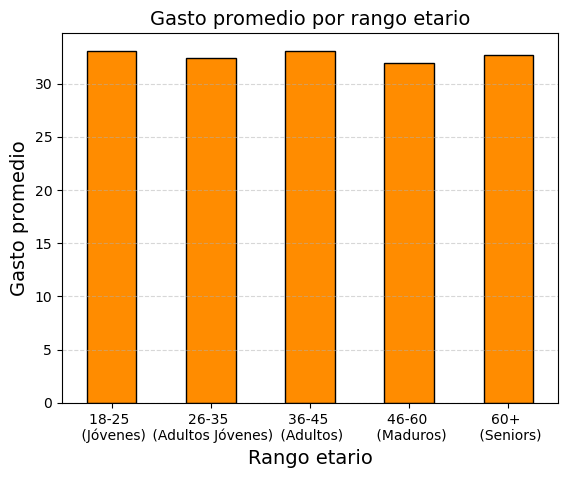

In [ ]:
#Gráfico sobre los que más gastan según la edad

franja_etaria = [17, 25, 35, 45, 60, 100]
etiquetas = ["18-25 \n (Jóvenes)","26-35 \n (Adultos Jóvenes)","36-45 \n (Adultos)","46-60 \n (Maduros)","60+ \n (Seniors)"]

df_restaurantes["rango_etario"] = pd.cut(df_restaurantes["edad"], bins=franja_etaria, labels=etiquetas)


promedios_por_rango = df_restaurantes.groupby("rango_etario", observed=False)["promedio_gasto_comida"].mean()

rango_ganador = promedios_por_rango.idxmax()
valor_maximo= promedios_por_rango.max()

print(f"Publico objetivo: El rango {rango_ganador} es el que más gasta (${valor_maximo:.2f})")

plt.Figure(figsize=(10,6))
promedios_por_rango.plot(kind="bar", color="darkorange", edgecolor= "black")

plt.title("Gasto promedio por rango etario", fontsize=14)
plt.xlabel("Rango etario", fontsize= 14)
plt.ylabel("Gasto promedio", fontsize= 14)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()


Gasto promedio por género

RESULTADO DE SEGMENTACIÓN POR GÉNERO
El género con mayor consumo promedio es: Femenino
Gasto promedio de este grupo: $32.74
Sin embargo, como la diferencia es muy poca podemos concluir que ambos consumen de igual manera


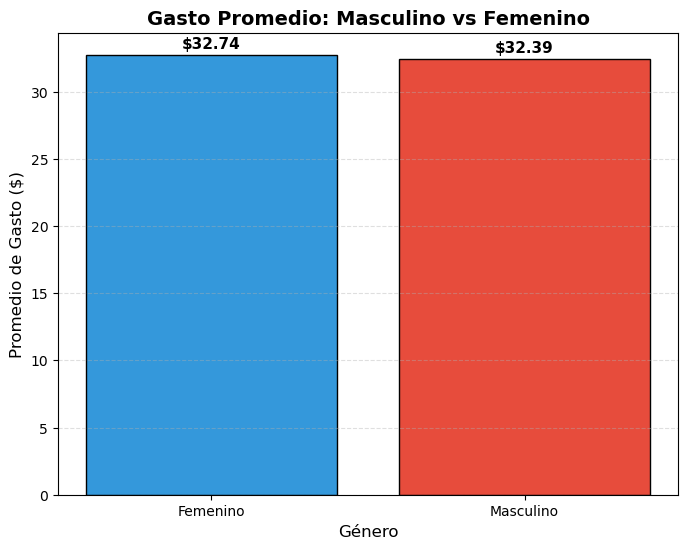

In [38]:
#Gráfico sobre los que más gastan según el genero

gasto_genero = df_restaurantes.groupby("genero", observed=False)["promedio_gasto_comida"].mean()

gasto_genero = gasto_genero.loc[gasto_genero.index.isin(['Masculino', 'Femenino'])]


plt.figure(figsize=(8, 6))

plt.bar(gasto_genero.index, gasto_genero.values, color=['#3498db', '#e74c3c'], edgecolor='black')

plt.title("Gasto Promedio: Masculino vs Femenino", fontsize=14, fontweight='bold')
plt.xlabel("Género", fontsize=12)
plt.ylabel("Promedio de Gasto ($)", fontsize=12)

for i, v in enumerate(gasto_genero.values):
    plt.text(i, v + 0.5, f"${v:.2f}", ha='center', fontweight='bold', fontsize=11)


genero_ganador = gasto_genero.idxmax()
valor_maximo_gen = gasto_genero.max()


print(f"RESULTADO DE SEGMENTACIÓN POR GÉNERO")
print(f"El género con mayor consumo promedio es: {genero_ganador}")
print(f"Gasto promedio de este grupo: ${valor_maximo_gen:.2f}")
print("Sin embargo, como la diferencia es muy poca podemos concluir que ambos consumen de igual manera")


plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

Gasto promedio por ciudad de residencia

ANÁLISIS GEOGRÁFICO DE VENTAS
La ciudad con el ticket promedio más alto es: Miami
Promedio de gasto en esa ciudad: $39.75


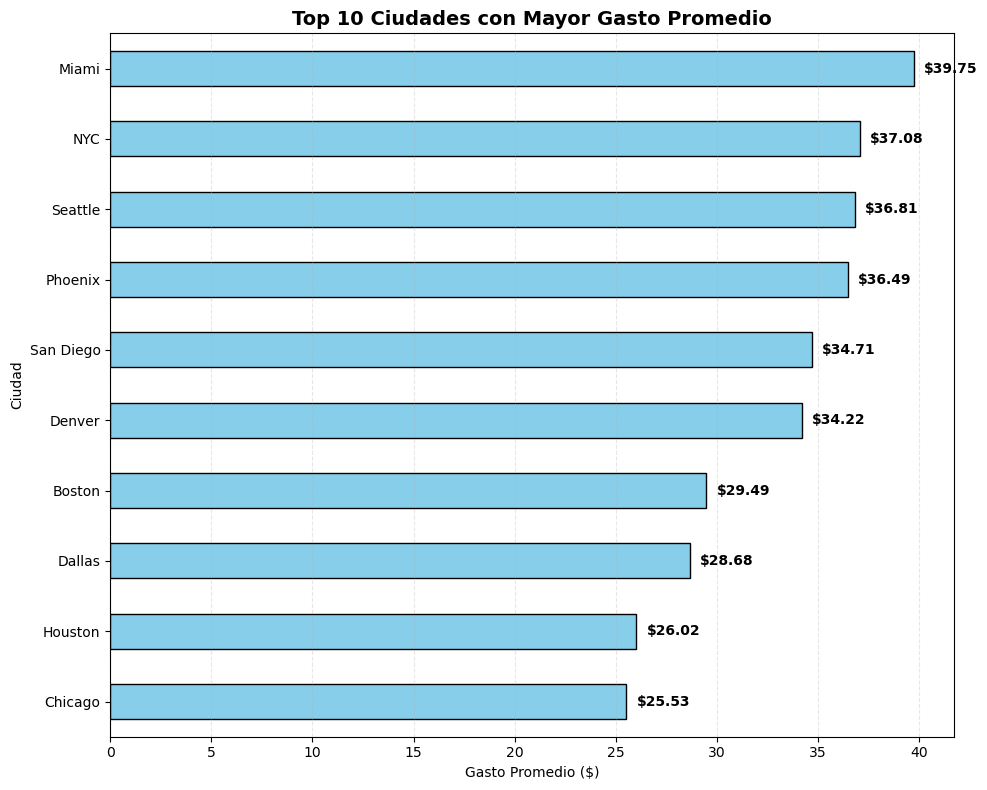

In [ ]:
#Gráfico sobre los que más gastan según la ciudad de residencia

top_ciudades = df_restaurantes.groupby("ciudad_residencia")["promedio_gasto_comida"].mean().sort_values(ascending=False).head(10)

ciudad_ganadora = top_ciudades.idxmax()
valor_max_ciudad = top_ciudades.max()

print(f"ANÁLISIS GEOGRÁFICO DE VENTAS")
print(f"La ciudad con el ticket promedio más alto es: {ciudad_ganadora}")
print(f"Promedio de gasto en esa ciudad: ${valor_max_ciudad:.2f}")

plt.figure(figsize=(10, 8))
top_ciudades.plot(kind='barh', color='skyblue', edgecolor='black')

plt.title("Top 10 Ciudades con Mayor Gasto Promedio", fontsize=14, fontweight='bold')
plt.xlabel("Gasto Promedio ($)")
plt.ylabel("Ciudad")


plt.gca().invert_yaxis() 

for i, v in enumerate(top_ciudades):
    plt.text(v + 0.5, i, f"${v:.2f}", va='center', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Gasto promedio por estracto económico

ANÁLISIS ESTRACTO ECONÓMICO
 El estracto enconómico que más consumo es: Muy Alto
Estracto que más consume: $64.26


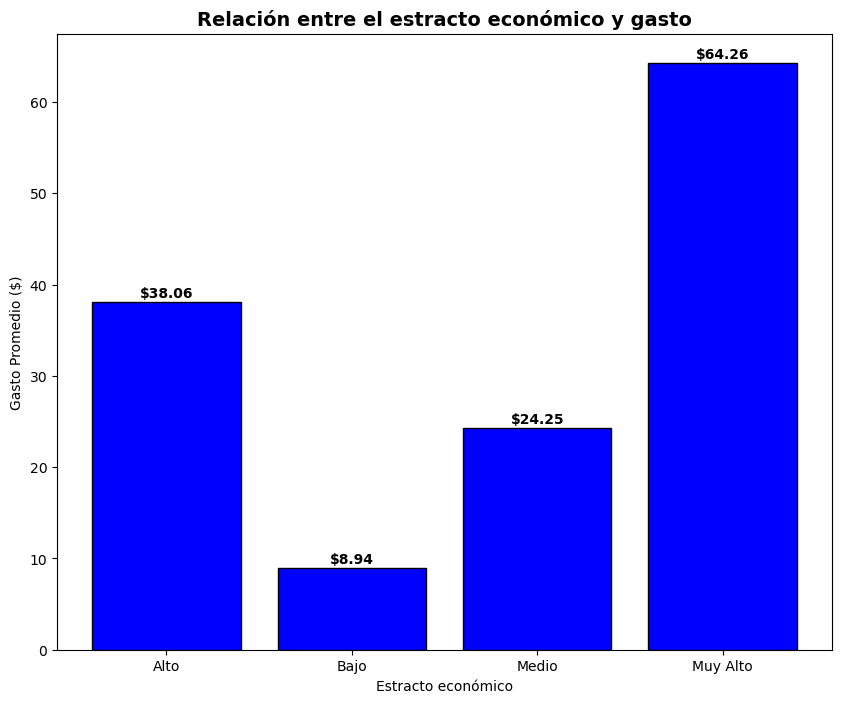

In [ ]:
#Gráfico sobre los que más gastan según la el estracto económico

top_estracto_economico = df_restaurantes.groupby("estrato_socioeconomico", observed=False)["promedio_gasto_comida"].mean().sort_index()

estracto_ganador = top_estracto_economico.idxmax()
valor_max_estracto = top_estracto_economico.max()

print(f"ANÁLISIS ESTRACTO ECONÓMICO")
print(f" El estracto enconómico que más consumo es: {estracto_ganador}")
print(f"Estracto que más consume: ${valor_max_estracto:.2f}")

plt.figure(figsize=(10, 8))

plt.bar(top_estracto_economico.index.astype(str), top_estracto_economico.values, color="blue", edgecolor='black')

plt.title("Relación entre el estracto económico y gasto", fontsize=14, fontweight='bold')
plt.xlabel("Estracto económico")
plt.ylabel("Gasto Promedio ($)")


for i, v in enumerate(top_estracto_economico.values):
    plt.text(i, v + 0.5, f"${v:.2f}", ha='center', fontweight='bold')

plt.show()

#### Conclusiones:
 El equipo de marketing debería enfocar su segmentación a personas de ambos sexos, de entre 36 y 45 años de la ciudad de Miami y con el poder adquisitivo alto y muy alto, para obtener los mejores resultados en sus campañas publicitarias, ya que son éstos los clientes que mayor consumo generan en el restaurant